# SSRN 高光谱分类教学 Notebook

这份 Notebook 将 `SSRN (Spectral-Spatial Residual Network)` 整理成一个可教学、可执行、可保存结果的单文件流程。

这里保留了 SSRN 的核心思想：

- 先在**光谱维度**做残差建模
- 再在**空间维度**做残差建模
- 最后完成高光谱 patch 的分类

目标不是完全复刻论文工程，而是把你当前仓库里的 `SSRN.py` 方法迁移成一份更适合学习和复现的 notebook。


## 本 Notebook 会完成什么

1. 读取 `Indian Pines` 数据与标签
2. 按 SSRN 当前脚本思路做标准化与 patch 提取
3. 构建谱域残差块和空间残差块
4. 训练 SSRN
5. 计算 OA、AA、Kappa 和分类报告
6. 生成整图预测结果并保存到 `results/ssrn/IP_notebook/`


In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.io import loadmat
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 1334
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']


device = cuda


## 1. 读取数据

这里仍然使用 `Indian Pines`。

- 数据立方体形状：`(height, width, bands)`
- 标签图形状：`(height, width)`
- 标签值 `0` 表示背景


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"].astype(np.float32)
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"].astype(np.int64)

print("cube shape:", cube.shape)
print("gt shape:", gt.shape)
print("num classes:", int(gt.max()))
print("labeled pixels:", int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
num classes: 16
labeled pixels: 10249


In [3]:
unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({"label": unique, "count": counts})
class_count_df = class_count_df[class_count_df["label"] != 0].copy()
class_count_df["class_name"] = class_count_df["label"].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[["label", "class_name", "count"]].sort_values("label")
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


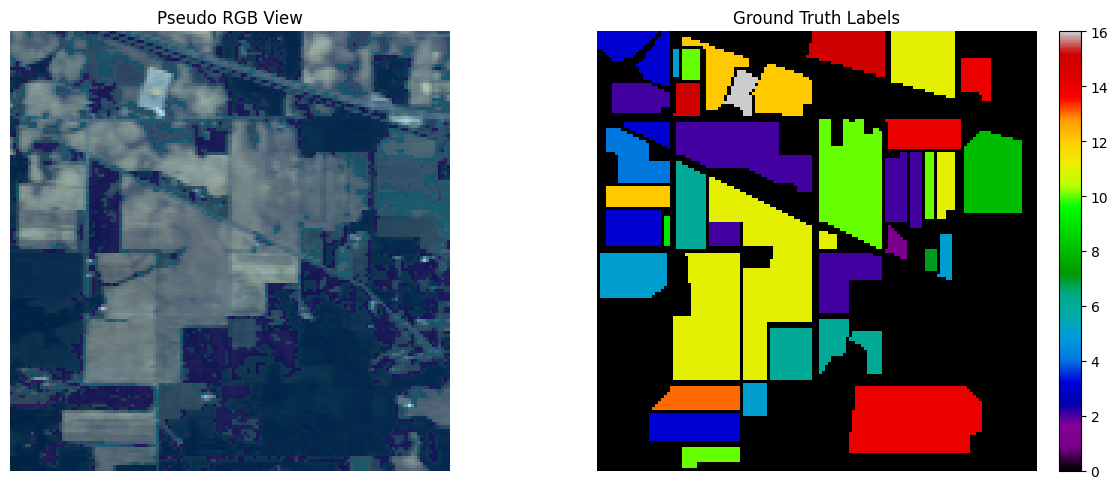

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB View")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. 标准化与分层采样

这里沿用当前 `SSRN.py` 的思路：

- 先对整个高光谱立方的每个波段做标准化
- 再按类别收集有标签像素
- 最后按每类 `20% / 10% / 70%` 划分训练、验证和测试

这种划分方式与当前 SSRN 脚本保持一致。


In [5]:
h, w, bands = cube.shape
num_classes = int(gt.max())

scaler = StandardScaler()
flat_cube = cube.reshape(-1, bands)
flat_cube = scaler.fit_transform(flat_cube).astype(np.float32)
norm_cube = flat_cube.reshape(h, w, bands)

class_indices = {c: [] for c in range(1, num_classes + 1)}
for i in range(h):
    for j in range(w):
        if gt[i, j] > 0:
            class_indices[gt[i, j]].append((i, j))

train_idx, val_idx, test_idx = [], [], []
rng = np.random.default_rng(SEED)
for c in range(1, num_classes + 1):
    indices = class_indices[c].copy()
    rng.shuffle(indices)
    n = len(indices)
    n_train = max(1, int(0.2 * n))
    n_val = max(1, int(0.1 * n))
    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val:])

print("train size:", len(train_idx))
print("val size:", len(val_idx))
print("test size:", len(test_idx))


train size: 2045
val size: 1018
test size: 7186


In [6]:
def split_labels(index_list):
    labels = np.array([gt[i, j] - 1 for i, j in index_list], dtype=np.int64)
    return labels


train_labels = split_labels(train_idx)
val_labels = split_labels(val_idx)
test_labels = split_labels(test_idx)


def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({"label": int(v + 1), "class_name": class_names[v], "count": int(c)})
    return pd.DataFrame(rows)


split_summary = pd.concat(
    [
        count_by_class(train_labels, class_names).assign(split="train"),
        count_by_class(val_labels, class_names).assign(split="val"),
        count_by_class(test_labels, class_names).assign(split="test"),
    ],
    ignore_index=True,
)
split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,9,train
1,2,Corn-notill,285,train
2,3,Corn-mintill,166,train
3,4,Corn,47,train
4,5,Grass-pasture,96,train
5,6,Grass-trees,146,train
6,7,Grass-pasture-mowed,5,train
7,8,Hay-windrowed,95,train
8,9,Oats,4,train
9,10,Soybean-notill,194,train


## 3. Patch 提取

SSRN 的输入不是单个像素，而是带空间邻域的高光谱 patch。

当前实现与原脚本保持一致：

- `patch_size = 7`
- 输入形状会整理成 `[N, 1, patch_size, patch_size, bands]`


In [7]:
PATCH_SIZE = 7
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 3e-4

pad = PATCH_SIZE // 2
padded_cube = np.pad(norm_cube, ((pad, pad), (pad, pad), (0, 0)), mode="constant")


def extract_patches(index_list):
    patches = np.zeros((len(index_list), PATCH_SIZE, PATCH_SIZE, bands), dtype=np.float32)
    labels = np.zeros(len(index_list), dtype=np.int64)
    for k, (i, j) in enumerate(index_list):
        patches[k] = padded_cube[i : i + PATCH_SIZE, j : j + PATCH_SIZE, :]
        labels[k] = gt[i, j] - 1
    return patches, labels


train_patches, train_labels = extract_patches(train_idx)
val_patches, val_labels = extract_patches(val_idx)
test_patches, test_labels = extract_patches(test_idx)
all_positions = train_idx + val_idx + test_idx
all_patches, all_labels = extract_patches(all_positions)

print("train patches:", train_patches.shape)
print("val patches:", val_patches.shape)
print("test patches:", test_patches.shape)


train patches: (2045, 7, 7, 200)
val patches: (1018, 7, 7, 200)
test patches: (7186, 7, 7, 200)


In [8]:
class HSIPatchDataset(Dataset):
    def __init__(self, patches, labels=None):
        self.patches = torch.from_numpy(patches).unsqueeze(1).float()
        self.labels = None if labels is None else torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.patches[idx]
        return self.patches[idx], self.labels[idx]


train_loader = DataLoader(HSIPatchDataset(train_patches, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(HSIPatchDataset(val_patches, val_labels), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(HSIPatchDataset(test_patches, test_labels), batch_size=256, shuffle=False)
all_loader = DataLoader(HSIPatchDataset(all_patches, labels=None), batch_size=256, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([16, 1, 7, 7, 200])

## 4. 定义 SSRN

这个实现保留了原脚本的两段式结构：

1. **Spectral stream**
   先用 `1x1x7` 卷积和谱域残差块建模光谱关系。
2. **Spatial stream**
   再用 `3x3x1` 风格的空间卷积和空间残差块建模邻域结构。


In [9]:
class SpectralResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv3d(channels, channels, (1, 1, 7), padding=(0, 0, 3))
        self.bn1 = nn.BatchNorm3d(channels)
        self.conv2 = nn.Conv3d(channels, channels, (1, 1, 7), padding=(0, 0, 3))
        self.shortcut = nn.Conv3d(channels, channels, (1, 1, 1))

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.conv2(out)
        return F.relu(identity + out)


class SpatialResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv3d(channels, channels, (3, 3, 1), padding=(1, 1, 0))
        self.bn1 = nn.BatchNorm3d(channels)
        self.conv2 = nn.Conv3d(channels, channels, (3, 3, 1), padding=(1, 1, 0))
        self.shortcut = nn.Conv3d(channels, channels, (1, 1, 1))

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.conv2(out)
        return F.relu(identity + out)


class SSRN(nn.Module):
    def __init__(self, num_classes, patch_size, input_bands):
        super().__init__()

        self.spectral_conv1 = nn.Sequential(
            nn.Conv3d(1, 24, (1, 1, 7), stride=(1, 1, 2)),
            nn.BatchNorm3d(24),
            nn.ReLU(True),
        )
        self.spectral_res = SpectralResBlock(24)
        self.spectral_bn = nn.BatchNorm3d(24)

        self.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, 1, patch_size, patch_size, input_bands)
            dummy = self.spectral_conv1(dummy)
            dummy = self.spectral_res(dummy)
            spectral_dim = dummy.shape[-1]

        self.transition_conv = nn.Conv3d(24, 128, (1, 1, spectral_dim))

        self.spatial_conv1 = nn.Sequential(
            nn.Conv3d(1, 24, (3, 3, 128)),
            nn.BatchNorm3d(24),
            nn.ReLU(True),
        )
        self.spatial_res = SpatialResBlock(24)
        self.spatial_bn = nn.BatchNorm3d(24)

        with torch.no_grad():
            dummy2 = torch.zeros(1, 1, patch_size, patch_size, 128)
            dummy2 = self.spatial_conv1(dummy2)
            dummy2 = self.spatial_res(dummy2)
            pool_size = (dummy2.shape[2], dummy2.shape[3], dummy2.shape[4])

        self.avg_pool = nn.AvgPool3d(pool_size)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(24, num_classes)

    def forward(self, x):
        x = self.spectral_conv1(x)
        x = self.spectral_res(x)
        x = F.relu(self.spectral_bn(x))

        x = self.transition_conv(x)
        x = x.permute(0, 4, 2, 3, 1)

        x = self.spatial_conv1(x)
        x = self.spatial_res(x)
        x = F.relu(self.spatial_bn(x))

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)


model = SSRN(num_classes=len(class_names), patch_size=PATCH_SIZE, input_bands=bands).to(device)
print("model parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
model


model parameters: 346,392


SSRN(
  (spectral_conv1): Sequential(
    (0): Conv3d(1, 24, kernel_size=(1, 1, 7), stride=(1, 1, 2))
    (1): BatchNorm3d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (spectral_res): SpectralResBlock(
    (conv1): Conv3d(24, 24, kernel_size=(1, 1, 7), stride=(1, 1, 1), padding=(0, 0, 3))
    (bn1): BatchNorm3d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv3d(24, 24, kernel_size=(1, 1, 7), stride=(1, 1, 1), padding=(0, 0, 3))
    (shortcut): Conv3d(24, 24, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  )
  (spectral_bn): BatchNorm3d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (transition_conv): Conv3d(24, 128, kernel_size=(1, 1, 97), stride=(1, 1, 1))
  (spatial_conv1): Sequential(
    (0): Conv3d(1, 24, kernel_size=(3, 3, 128), stride=(1, 1, 1))
    (1): BatchNorm3d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (s

In [10]:
@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred


output_dir = Path("results/ssrn/IP_notebook")
output_dir.mkdir(parents=True, exist_ok=True)
best_model_path = output_dir / "best_model.pth"

optimizer = optim.RMSprop(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
}


## 5. 训练模型

这里沿用当前 SSRN 脚本的优化器选择：`RMSprop`。
训练过程中记录训练损失、训练准确率和验证准确率，并保存验证集最优权重。


In [11]:
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

print("best_val_acc =", round(best_val_acc, 4))


Epoch 01/10 | loss=2.1681 | train_acc=0.4059 | val_acc=0.6542


Epoch 02/10 | loss=1.7368 | train_acc=0.5760 | val_acc=0.7181


Epoch 03/10 | loss=1.5271 | train_acc=0.6117 | val_acc=0.8124


Epoch 04/10 | loss=1.3145 | train_acc=0.6606 | val_acc=0.8772


Epoch 05/10 | loss=1.1660 | train_acc=0.6949 | val_acc=0.9175


Epoch 06/10 | loss=1.0524 | train_acc=0.7252 | val_acc=0.9155


Epoch 07/10 | loss=0.9249 | train_acc=0.7707 | val_acc=0.9204


Epoch 08/10 | loss=0.8280 | train_acc=0.7853 | val_acc=0.9548


Epoch 09/10 | loss=0.7819 | train_acc=0.7868 | val_acc=0.9479


Epoch 10/10 | loss=0.7133 | train_acc=0.8127 | val_acc=0.9558
best_val_acc = 0.9558


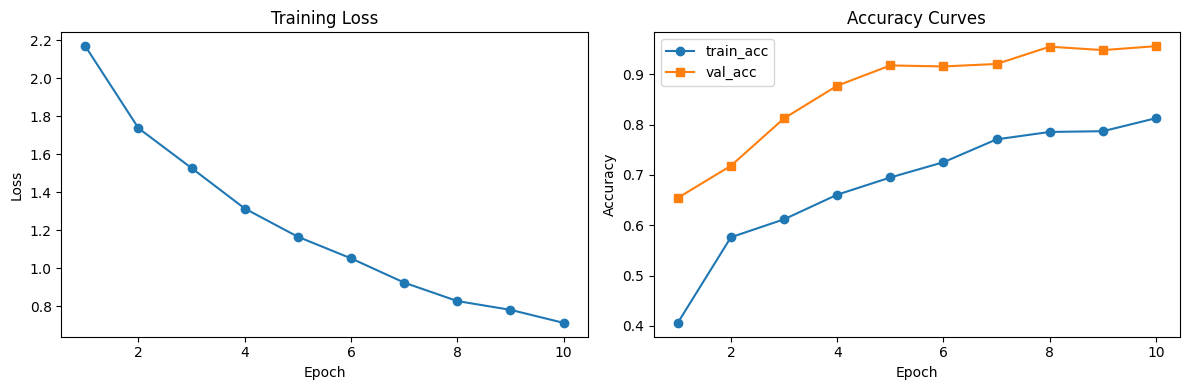

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epoch_index, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epoch_index, history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. 测试集评估

这里计算：

- `OA`
- `AA`
- `Kappa`
- 分类报告
- 每类准确率


In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

per_class_acc = []
for c in range(len(class_names)):
    mask = y_true_test == c
    acc = float((y_pred_test[mask] == c).mean()) if mask.sum() > 0 else 0.0
    per_class_acc.append(acc)

print("Test accuracy:", round(test_acc, 4))
print("OA:", round(oa, 4))
print("AA:", round(aa, 4))
print("Kappa:", round(kappa, 4))


Test accuracy: 0.9602
OA: 0.9602
AA: 0.7594
Kappa: 0.9546


In [14]:
report = classification_report(
    y_true_test,
    y_pred_test,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     0.0000    0.0000    0.0000        33
                 Corn-notill     0.9432    0.9950    0.9684      1001
                Corn-mintill     0.9862    0.9811    0.9836       581
                        Corn     1.0000    0.3473    0.5156       167
               Grass-pasture     0.9417    1.0000    0.9700       339
                 Grass-trees     0.9808    1.0000    0.9903       511
         Grass-pasture-mowed     0.0000    0.0000    0.0000        21
               Hay-windrowed     0.7517    1.0000    0.8582       336
                        Oats     0.0000    0.0000    0.0000        14
              Soybean-notill     0.9653    0.9398    0.9524       681
             Soybean-mintill     0.9848    0.9808    0.9828      1719
               Soybean-clean     0.9509    0.9784    0.9645       416
                       Wheat     1.0000    1.0000    1.0000       144
                   

In [15]:
pd.DataFrame(
    {
        "label": np.arange(1, len(class_names) + 1),
        "class_name": class_names,
        "class_accuracy": per_class_acc,
    }
)


,label,class_name,class_accuracy
0,1,Alfalfa,0.000000
1,2,Corn-notill,0.995005
2,3,Corn-mintill,0.981067
3,4,Corn,0.347305
4,5,Grass-pasture,1.000000
5,6,Grass-trees,1.000000
6,7,Grass-pasture-mowed,0.000000
7,8,Hay-windrowed,1.000000
8,9,Oats,0.000000
9,10,Soybean-notill,0.939794


## 7. 整图预测

为了和其他教学 notebook 对齐，这里对全部有标签像素构造 patch，并还原成二维预测图。


In [16]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    preds = []
    for xb in data_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


all_pred = predict_all(model, all_loader)
pred_map = np.zeros_like(gt)
for (i, j), pred in zip(all_positions, all_pred):
    pred_map[i, j] = pred + 1

print("pred_map shape:", pred_map.shape)
print("nonzero predictions:", int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


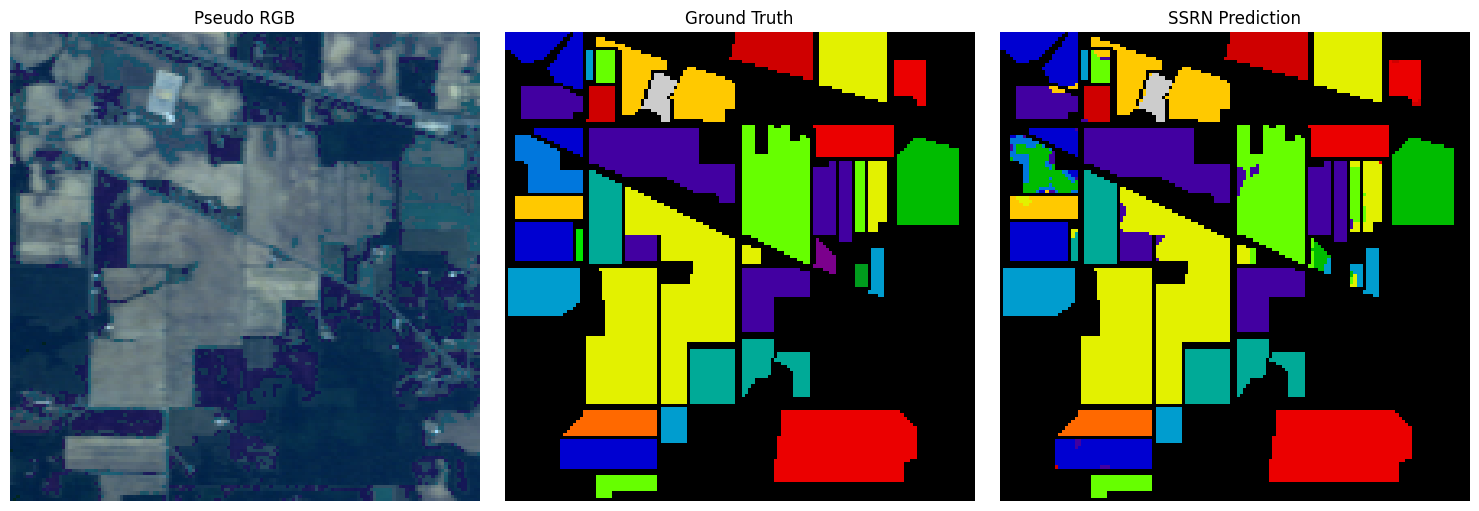

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[2].set_title("SSRN Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 8. 保存结果

这里把训练曲线、预测图、指标和分类报告保存到 `results/ssrn/IP_notebook/`。


In [18]:
metrics = {
    "seed": SEED,
    "patch_size": PATCH_SIZE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "oa": float(oa),
    "aa": float(aa),
    "kappa": float(kappa),
    "best_val_acc": float(best_val_acc),
}

(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(output_dir / "classification_report.txt").write_text(report, encoding="utf-8")
class_count_df.to_csv(output_dir / "class_distribution.csv", index=False)
split_summary.to_csv(output_dir / "split_summary.csv", index=False)
pd.DataFrame(
    {
        "label": np.arange(1, len(class_names) + 1),
        "class_name": class_names,
        "class_accuracy": per_class_acc,
    }
).to_csv(output_dir / "per_class_accuracy.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].plot(np.arange(1, EPOCHS + 1), history["train_acc"], marker="o", label="train_acc")
axes[1].plot(np.arange(1, EPOCHS + 1), history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "training_curves.png", dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("SSRN Prediction")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(output_dir / "prediction_map.png", dpi=200)
plt.close(fig)

print("saved to", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\ssrn\IP_notebook
['best_model.pth', 'class_distribution.csv', 'classification_report.txt', 'metrics.json', 'per_class_accuracy.csv', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 9. 小结

这份 Notebook 把当前 SSRN 方法整理成了一个适合学习和复现的单文件流程：

- 保留了谱域残差块和空间残差块
- 保持了 `Indian Pines` 的 patch 分类思路
- 保存了训练曲线、指标与预测图

从建模角度看，SSRN 是理解“先谱域、后空间”这一类高光谱网络结构的一个很有代表性的例子。
